In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv("custumer.csv")
df.shape

(5020, 14)

In [4]:
numeric_cols = ["Age", "TenureYears", "MonthlyCharges", "TotalCharges", "SupportCalls"]
df[numeric_cols].head()

,Age,TenureYears,MonthlyCharges,TotalCharges,SupportCalls
0,56.0,0,20.41,131.92,3
1,69.0,9,21.10,2394.45,1
2,46.0,3,61.66,2755.45,3
3,32.0,8,35.50,3796.58,2
4,60.0,9,86.45,10188.80,3


I'm keeping this to the 5 numerical columns in the dataset: **Age, TenureYears, MonthlyCharges, TotalCharges, SupportCalls**. CustomerID is an identifier column so it's excluded (it doesn't carry any real numeric meaning).

## 1. Correlation Matrix & Heatmap

### Concept

A correlation matrix is just every pairwise correlation (the same Pearson's r from the bivariate notebook) laid out in a grid, so you can see all the relationships between numerical columns in one place instead of checking them two at a time. A **heatmap** is the same matrix but colour-coded, which makes it much faster to scan for strong relationships - dark/bright cells jump out immediately instead of having to read every number.

### Example

- Simple example: comparing test scores across 5 subjects for a class - a correlation matrix shows which subjects tend to be scored similarly by the same students.
- Real-world example: a fitness tracker comparing steps, calories burned, heart rate and sleep hours all at once.
- Business example: a retail company comparing footfall, sales, discount percentage and ad spend together to see which metrics move in sync.
- AI/ML use case: the correlation matrix below across all 5 numerical columns in this dataset.

Why this matters for EDA: this is the fastest way to catch **multicollinearity** across many features at once, and to get a first sense of which numerical features might be worth keeping for a model.

In [6]:
corr_matrix = df[numeric_cols].corr()
corr_matrix.round(2)

,Age,TenureYears,MonthlyCharges,TotalCharges,SupportCalls
Age,1.00,0.02,-0.01,0.01,-0.00
TenureYears,0.02,1.00,-0.01,0.78,-0.03
MonthlyCharges,-0.01,-0.01,1.00,0.52,0.02
TotalCharges,0.01,0.78,0.52,1.00,-0.02
SupportCalls,-0.00,-0.03,0.02,-0.02,1.00


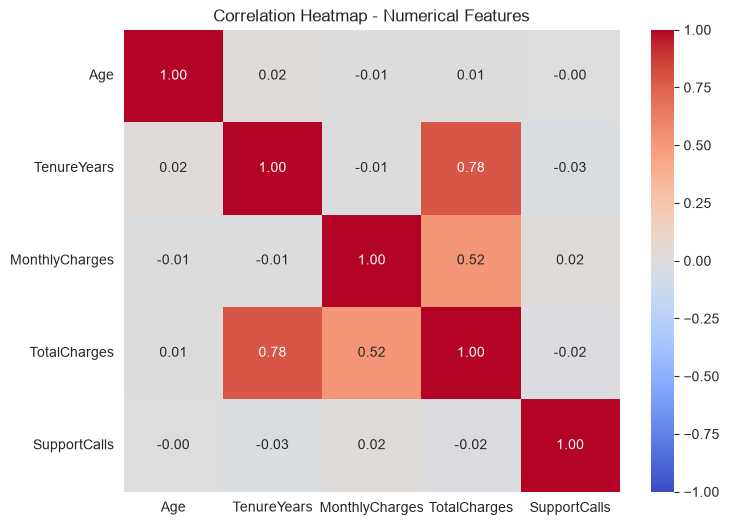

In [7]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation Heatmap - Numerical Features")
plt.show()

**Interpretation:** Most cells in the heatmap are close to white/light (near 0), except TenureYears vs TotalCharges which stands out clearly in a darker shade - matching the 0.78 correlation I already found in the bivariate notebook. Everything else (Age, MonthlyCharges, SupportCalls against each other) is weak, close to 0 in both directions.

**Insight:** Out of all 5 numerical columns, only one pair (TenureYears and TotalCharges) has a meaningful linear relationship. The rest of the numerical features look mostly independent of each other, which is actually a good sign - it means each one is likely carrying separate information rather than repeating what another column already tells us.

**AI/ML Relevance:** A heatmap like this is usually the first thing to check before feature selection. Since only one pair shows strong correlation here, multicollinearity isn't a widespread problem in this dataset - it's isolated to just the Tenure/TotalCharges pair, which is already flagged from the bivariate notebook.

## 2. Pair Plot

### Concept

A pair plot puts scatter plots for every pair of numerical columns into a single grid, with histograms (or KDE curves) down the diagonal for each individual column. It's basically a way to see every bivariate relationship *and* every individual distribution in one image, instead of generating each scatter plot separately.

### Example

- Simple example: comparing height, weight and age of a group of people all at once in one grid.
- Real-world example: an environmental dataset comparing temperature, humidity and rainfall together.
- Business example: comparing price, quantity sold and profit margin across products.
- AI/ML use case: the pair plot below across the numerical columns, colour-split by Churn so I can see if any pair of features separates churners from non-churners.

Why this matters for EDA: a pair plot can reveal patterns a single correlation number would miss - for example, two features could look uncorrelated overall (near-zero r) but still show a clear split when colour-coded by the target.

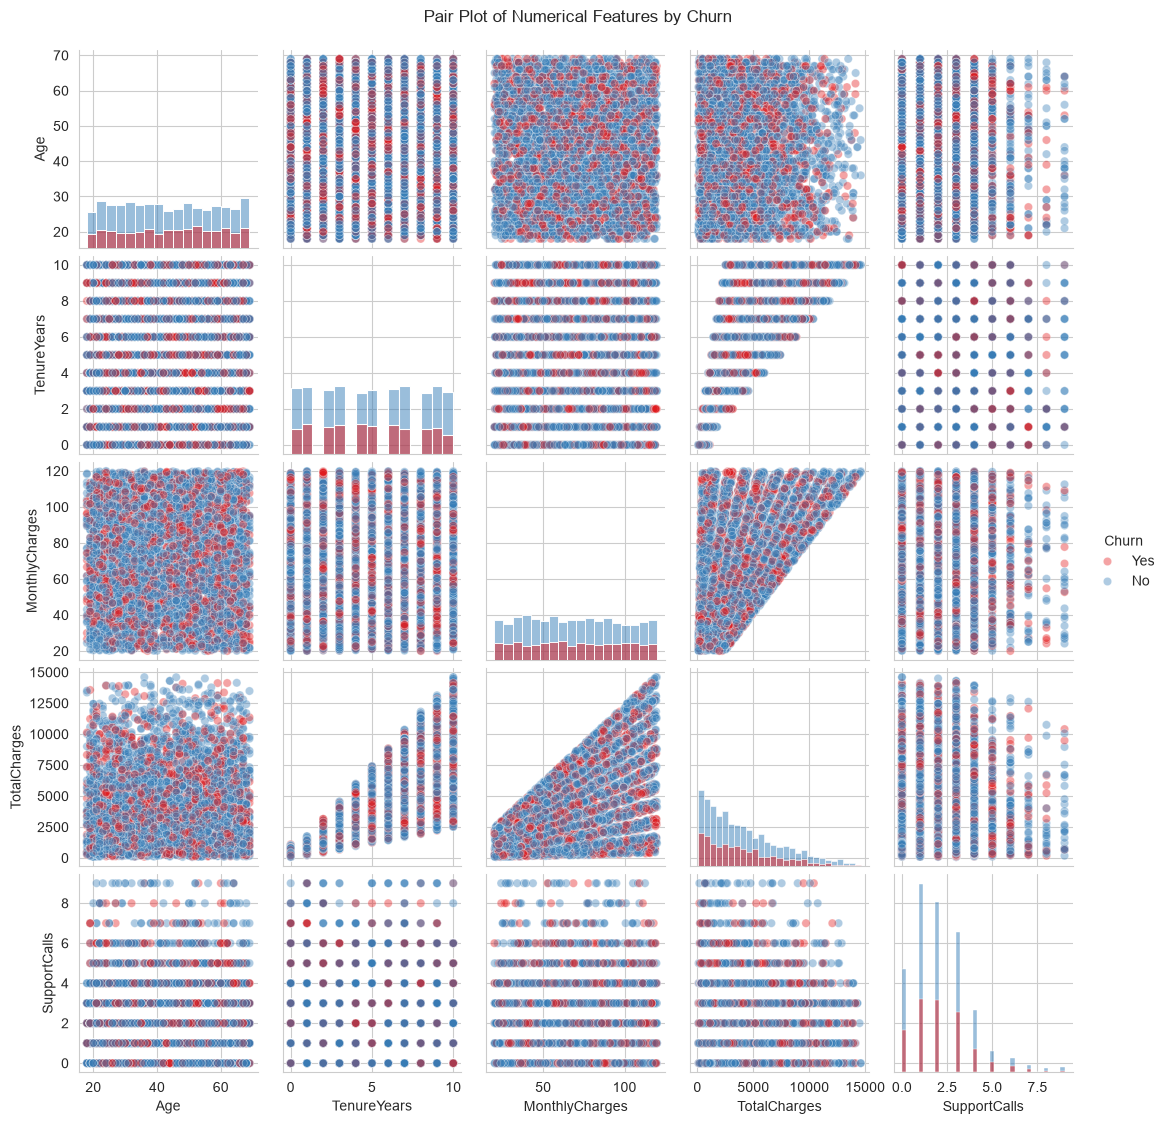

In [8]:
sns.pairplot(df.dropna(subset=numeric_cols), vars=numeric_cols, hue="Churn",
             plot_kws={"alpha": 0.4}, diag_kind="hist", palette="Set1", height=2.2)
plt.suptitle("Pair Plot of Numerical Features by Churn", y=1.02)
plt.show()

**Interpretation:** The diagonal histograms show Age and TenureYears are fairly evenly spread, while TotalCharges is right-skewed (a lot of lower values, fewer very high ones). Looking at the off-diagonal scatter panels, the Churn=Yes and Churn=No points are mixed together almost everywhere - I don't see a panel where the two colours clearly separate into different regions. The TenureYears vs TotalCharges panel again stands out as the only one with a clear diagonal-shaped trend.

**Insight:** No single pair of numerical features cleanly separates churners from non-churners just by looking at the scatter shape. This lines up with what I found in the bivariate notebook - Churn doesn't seem to be driven by any one or two numerical columns on their own.

**AI/ML Relevance:** This tells me a simple 2-feature model (like a basic logistic regression on just two numerical columns) probably won't do a great job predicting Churn. A model would likely need to combine several features, including the categorical ones, to find a usable pattern - this is useful to note for the modelling sprint later.

## 3. Feature Interactions

### Concept

Sometimes a feature's effect on another variable depends on the value of a third feature - this is called an **interaction**. A simple way to check this without doing a full statistical model is to group by one categorical column and re-check a numerical-numerical relationship within each group, to see if the relationship changes.

### Example

- Simple example: the relationship between study hours and marks might be stronger for students in one school than another.
- Real-world example: exercise and weight loss might relate differently depending on diet type.
- Business example: ad spend and sales might correlate more strongly in one region than another.
- AI/ML use case: checking whether TenureYears vs TotalCharges holds the same strength within each ContractType group, below.

In [9]:
for contract in df["ContractType"].unique():
    subset = df[df["ContractType"] == contract]
    r = subset["TenureYears"].corr(subset["TotalCharges"])
    print(f"{contract:<16} -> correlation: {r:.3f}  (n={len(subset)})")

One year         -> correlation: 0.770  (n=1214)
Two year         -> correlation: 0.790  (n=1570)
Month-to-month   -> correlation: 0.788  (n=2236)


**Interpretation:** The TenureYears vs TotalCharges correlation stays strong and roughly similar across all three contract types - it doesn't fall apart or flip sign in any group.

**Insight:** This particular relationship isn't dependent on ContractType - it holds consistently no matter which contract a customer is on, which makes sense since TotalCharges accumulates with tenure regardless of the plan type.

**AI/ML Relevance:** Not every relationship needs an interaction term in a model. Since this one is stable across groups, there's no strong case for engineering a Tenure x ContractType interaction feature - it would likely just add complexity without much benefit.